# 이진 분류 프로젝트 — EDA + 전처리 + 유의성 검증

**데이터셋**: Heart Failure Prediction (`fedesoriano/heart-failure-prediction`, Kaggle)  
**타겟**: `HeartDisease` (0: 정상, 1: 심장병)  

---

## 목차
1. 환경 설정
2. 데이터 로드
3. EDA
   - 3.1 기초 통계량
   - 3.2 결측치 분석
   - 3.3 데이터타입 분석
   - 3.4 이상치 시각화 (IQR 기반)
   - 3.5 피처 분포
   - 3.6 클래스 분포 분석
     - 3.6.1 피처 × 타겟 교차 분포
     - 3.6.2 타겟 분리도 지표
4. 전처리
   - 4.1 중복 데이터 제거
   - 4.2 결측치 처리
   - 4.3 이상치 처리
   - 4.4 인코딩
   - 4.5 스케일링
   - 4.6 전처리 결과 요약
5. 유의성 검증 (WoE / IV)
   - 5.1 IV Bar Chart
   - 5.2 WoE Binning Plot

## 1. 환경 설정

In [5]:
# # 필요 패키지 설치 (최초 1회)
# !pip install kagglehub pandas numpy matplotlib seaborn scipy scikit-learn catboost xgboost lightgbm -q

In [30]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler

In [6]:
import os
import warnings
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# 한글 폰트 설정 (Windows: Malgun Gothic / Mac: AppleGothic / Linux: NanumGothic)
_avail_fonts = {f.name for f in fm.fontManager.ttflist}
for _font in ['Malgun Gothic', 'NanumGothic', 'NanumBarunGothic', 'AppleGothic', 'DejaVu Sans']:
    if _font in _avail_fonts:
        plt.rcParams['font.family'] = _font
        print(f'폰트 설정: {_font}')
        break
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

print('라이브러리 로드 완료')

폰트 설정: Malgun Gothic
라이브러리 로드 완료


## 2. 데이터 로드

In [7]:
path = kagglehub.dataset_download('fedesoriano/heart-failure-prediction')
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, csv_files[0]))

TARGET = 'HeartDisease'

n_rows, n_cols = df.shape
print(f'파일: {csv_files[0]}')
print(f'Shape: {n_rows:,}행 x {n_cols}열')
print(f'타겟 컬럼: {TARGET}')
df.head()

100%|██████████| 8.56k/8.56k [00:00<00:00, 8.76MB/s]

Extracting files...
파일: heart.csv
Shape: 918행 x 12열
타겟 컬럼: HeartDisease


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0000,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0000,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0000,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5000,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0000,Up,0


In [8]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
dt_cols  = df.select_dtypes(include='datetime64').columns.tolist()

num_feats = [c for c in num_cols if c != TARGET]
cat_feats = [c for c in cat_cols if c != TARGET]
all_feats = num_feats + cat_feats

print(f'수치형 피처 ({len(num_feats)}개): {num_feats}')
print(f'범주형 피처 ({len(cat_feats)}개): {cat_feats}')
print(f'시간형 피처 ({len(dt_cols)}개): {dt_cols}')
print(f'타겟: {TARGET}')

수치형 피처 (6개): ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
범주형 피처 (5개): ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
시간형 피처 (0개): []
타겟: HeartDisease


## 3. EDA

---

### 3.1 기초 통계량

각 컬럼의 `count`, `mean`, `std`, `min`, `max`, 25% / 50% / 75% 백분위수

In [10]:
stats_df = df[num_feats + [TARGET]].describe().T
stats_df.columns.name = None
stats_df.index.name = 'Feature'

display(
    stats_df.style
    .background_gradient(cmap='Blues', subset=['mean', 'std'])
    .background_gradient(cmap='Greens', subset=['min', 'max'])
    .background_gradient(cmap='Purples', subset=['25%', '50%', '75%'])
    .format('{:.3f}')
    .set_caption('수치형 피처 기초 통계량')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px')]
    }])
)

,count,mean,std,min,25%,50%,75%,max
Feature,,,,,,,,
Age,918.000,53.511,9.433,28.000,47.000,54.000,60.000,77.000
RestingBP,918.000,132.397,18.514,0.000,120.000,130.000,140.000,200.000
Cholesterol,918.000,198.800,109.384,0.000,173.250,223.000,267.000,603.000
FastingBS,918.000,0.233,0.423,0.000,0.000,0.000,0.000,1.000
MaxHR,918.000,136.809,25.460,60.000,120.000,138.000,156.000,202.000
Oldpeak,918.000,0.887,1.067,-2.600,0.000,0.600,1.500,6.200
HeartDisease,918.000,0.553,0.497,0.000,0.000,1.000,1.000,1.000


### 3.2 결측치 분석

컬럼별 결측 건수 및 전체 데이터셋 대비 결측률(%)

In [11]:
miss_count = df.isnull().sum()
miss_pct   = (miss_count / len(df) * 100).round(2)
miss_df    = pd.DataFrame({'결측 건수': miss_count, '결측률(%)': miss_pct})

total_miss = int(miss_df['결측 건수'].sum())
print(f'전체 결측치 합계: {total_miss}')

display(
    miss_df.style
    .background_gradient(cmap='Reds', subset=['결측 건수'])
    .format({'결측률(%)': '{:.2f}%'})
    .set_caption('컬럼별 결측치 현황')
)

if total_miss > 0:
    miss_only = miss_df[miss_df['결측 건수'] > 0].sort_values('결측률(%)', ascending=False)
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(miss_only.index, miss_only['결측률(%)'],
                  color='#e74c3c', alpha=0.85, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, miss_only['결측률(%)']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(miss_only['결측률(%)']) * 0.01,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
    ax.set_title('컬럼별 결측률', fontsize=13, fontweight='bold')
    ax.set_ylabel('결측률 (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('결측치 없음 — 시각화 생략')

전체 결측치 합계: 0


,결측 건수,결측률(%)
Age,0,0.00%
Sex,0,0.00%
ChestPainType,0,0.00%
RestingBP,0,0.00%
Cholesterol,0,0.00%
FastingBS,0,0.00%
RestingECG,0,0.00%
MaxHR,0,0.00%
ExerciseAngina,0,0.00%
Oldpeak,0,0.00%


결측치 없음 — 시각화 생략


### 3.3 데이터타입 분석

컬럼별 수치형 / 범주형 / 시간형 분류 및 카디널리티(고유값 수)

In [12]:
def _col_type(col):
    if col in dt_cols:
        return '시간형'
    elif col in cat_cols:
        return '범주형'
    elif col in num_cols:
        return '수치형'
    return '기타'

type_info = pd.DataFrame({
    '컬럼':      df.columns.tolist(),
    'dtype':     df.dtypes.astype(str).values,
    '분류':      [_col_type(c) for c in df.columns],
    '카디널리티': [df[c].nunique() for c in df.columns],
    '결측 수':   [int(df[c].isnull().sum()) for c in df.columns],
    '샘플값':    [
        str(df[c].dropna().sample(min(3, df[c].nunique()), random_state=42).tolist())
        for c in df.columns
    ]
}).set_index('컬럼')

_COLOR_MAP = {'수치형': 'color: #2980b9; font-weight:bold',
              '범주형': 'color: #e67e22; font-weight:bold',
              '시간형': 'color: #27ae60; font-weight:bold',
              '기타':   'color: #7f8c8d; font-weight:bold'}

display(
    type_info.style
    .apply(lambda s: [_COLOR_MAP.get(v, '') for v in s], subset=['분류'])
    .background_gradient(cmap='Blues', subset=['카디널리티'])
    .set_caption('컬럼별 데이터타입 및 카디널리티')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold')]
    }])
)

print(f'\n수치형: {len(num_cols)}개  |  범주형: {len(cat_cols)}개  |  시간형: {len(dt_cols)}개')

,dtype,분류,카디널리티,결측 수,샘플값
컬럼,,,,,
Age,int64,수치형,50,0,"[63, 53, 65]"
Sex,str,범주형,2,0,"['F', 'M']"
ChestPainType,str,범주형,4,0,"['ATA', 'NAP', 'ASY']"
RestingBP,int64,수치형,67,0,"[140, 145, 160]"
Cholesterol,int64,수치형,222,0,"[195, 518, 0]"
FastingBS,int64,수치형,2,0,"[0, 0]"
RestingECG,str,범주형,3,0,"['Normal', 'Normal', 'ST']"
MaxHR,int64,수치형,119,0,"[179, 130, 122]"
ExerciseAngina,str,범주형,2,0,"['N', 'N']"



수치형: 7개  |  범주형: 5개  |  시간형: 0개


### 3.4 이상치 시각화 (IQR 기반)

IQR 방식으로 이상치 건수를 산출하고 박스플롯으로 시각화합니다.  
이상치 기준: `Q1 - 1.5×IQR` 또는 `Q3 + 1.5×IQR` 초과/미만

,이상치 건수,이상치율(%)
FastingBS,214,23.31%
Cholesterol,183,19.93%
RestingBP,28,3.05%
Oldpeak,16,1.74%
MaxHR,2,0.22%
Age,0,0.00%


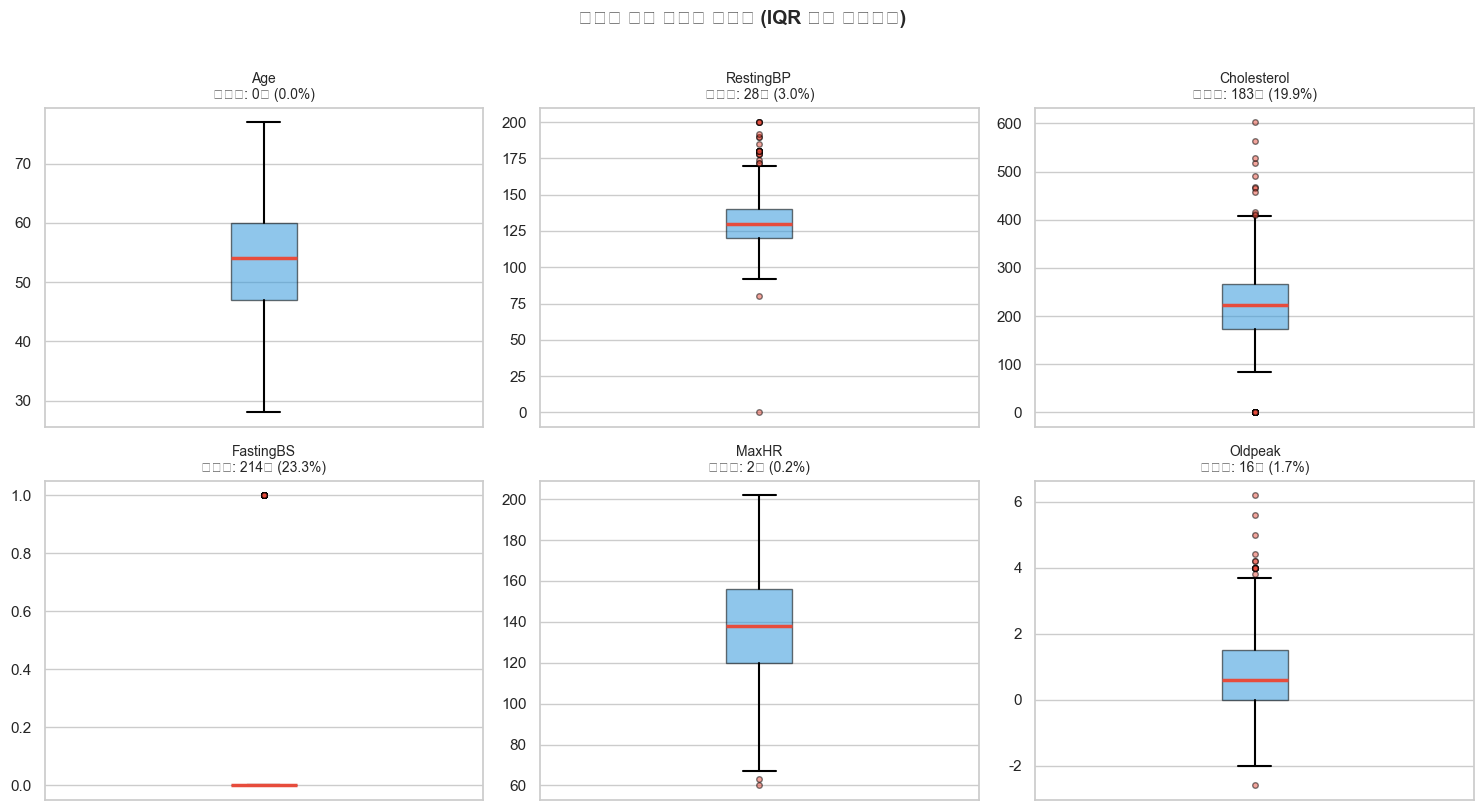

In [13]:
def _iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return int(((series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)).sum())

outlier_info = {col: _iqr_outlier_count(df[col]) for col in num_feats}
outlier_df = pd.DataFrame.from_dict(outlier_info, orient='index', columns=['이상치 건수'])
outlier_df['이상치율(%)'] = (outlier_df['이상치 건수'] / len(df) * 100).round(2)

display(
    outlier_df.sort_values('이상치 건수', ascending=False).style
    .background_gradient(cmap='Oranges', subset=['이상치 건수'])
    .format({'이상치율(%)': '{:.2f}%'})
    .set_caption('IQR 기반 이상치 요약')
)

# 박스플롯 그리드
N_COLS = 3
n_rows = -(-len(num_feats) // N_COLS)
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(15, 4 * n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(num_feats):
    data = df[col].dropna()
    bp = axes[i].boxplot(
        data, patch_artist=True, notch=False,
        medianprops=dict(color='#e74c3c', linewidth=2.5),
        boxprops=dict(facecolor='#3498db', alpha=0.55),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markerfacecolor='#e74c3c',
                        markersize=4, alpha=0.5, linewidth=0)
    )
    oc = outlier_info[col]
    op = outlier_df.loc[col, '이상치율(%)']
    axes[i].set_title(f'{col}\n이상치: {oc}건 ({op:.1f}%)', fontsize=10)
    axes[i].set_xticks([])

for j in range(len(num_feats), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('수치형 피처 이상치 시각화 (IQR 기반 박스플롯)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.5 피처 분포

- **수치형**: 히스토그램 + KDE 곡선  
- **범주형**: 빈도표 + 빈도 바차트

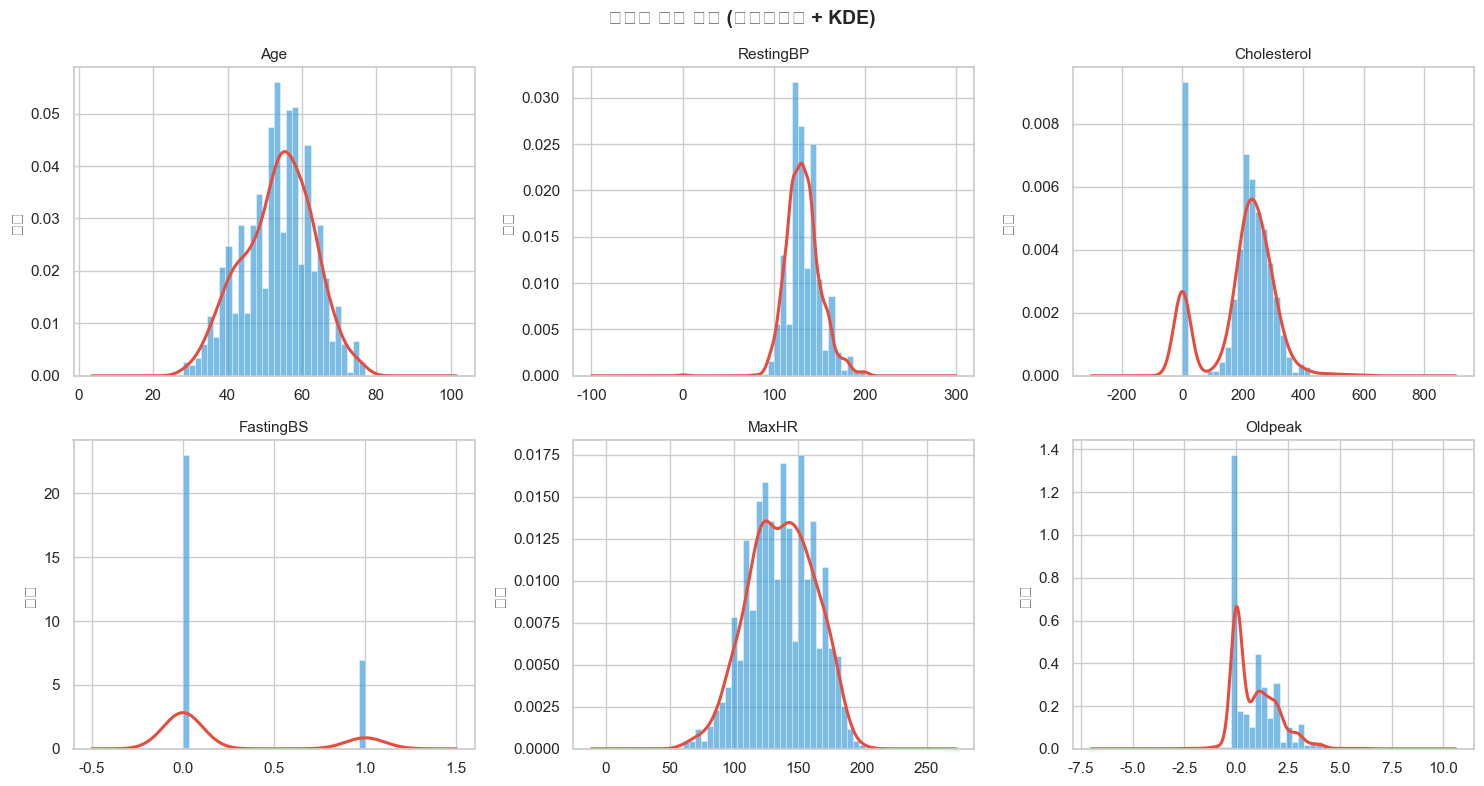

In [14]:
# ── 수치형: 히스토그램 + KDE ──────────────────────────────────────────────────
N_COLS = 3
n_rows = -(-len(num_feats) // N_COLS)
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(15, 4 * n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(num_feats):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color='#3498db', alpha=0.65,
                 density=True, edgecolor='white', linewidth=0.4)
    data.plot.kde(ax=axes[i], color='#e74c3c', linewidth=2.2)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('밀도')

for j in range(len(num_feats), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('수치형 피처 분포 (히스토그램 + KDE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

,Sex,빈도,비율(%)
0,M,725,78.98%
1,F,193,21.02%


,ChestPainType,빈도,비율(%)
0,ASY,496,54.03%
1,NAP,203,22.11%
2,ATA,173,18.85%
3,TA,46,5.01%


,RestingECG,빈도,비율(%)
0,Normal,552,60.13%
1,LVH,188,20.48%
2,ST,178,19.39%


,ExerciseAngina,빈도,비율(%)
0,N,547,59.59%
1,Y,371,40.41%


,ST_Slope,빈도,비율(%)
0,Flat,460,50.11%
1,Up,395,43.03%
2,Down,63,6.86%


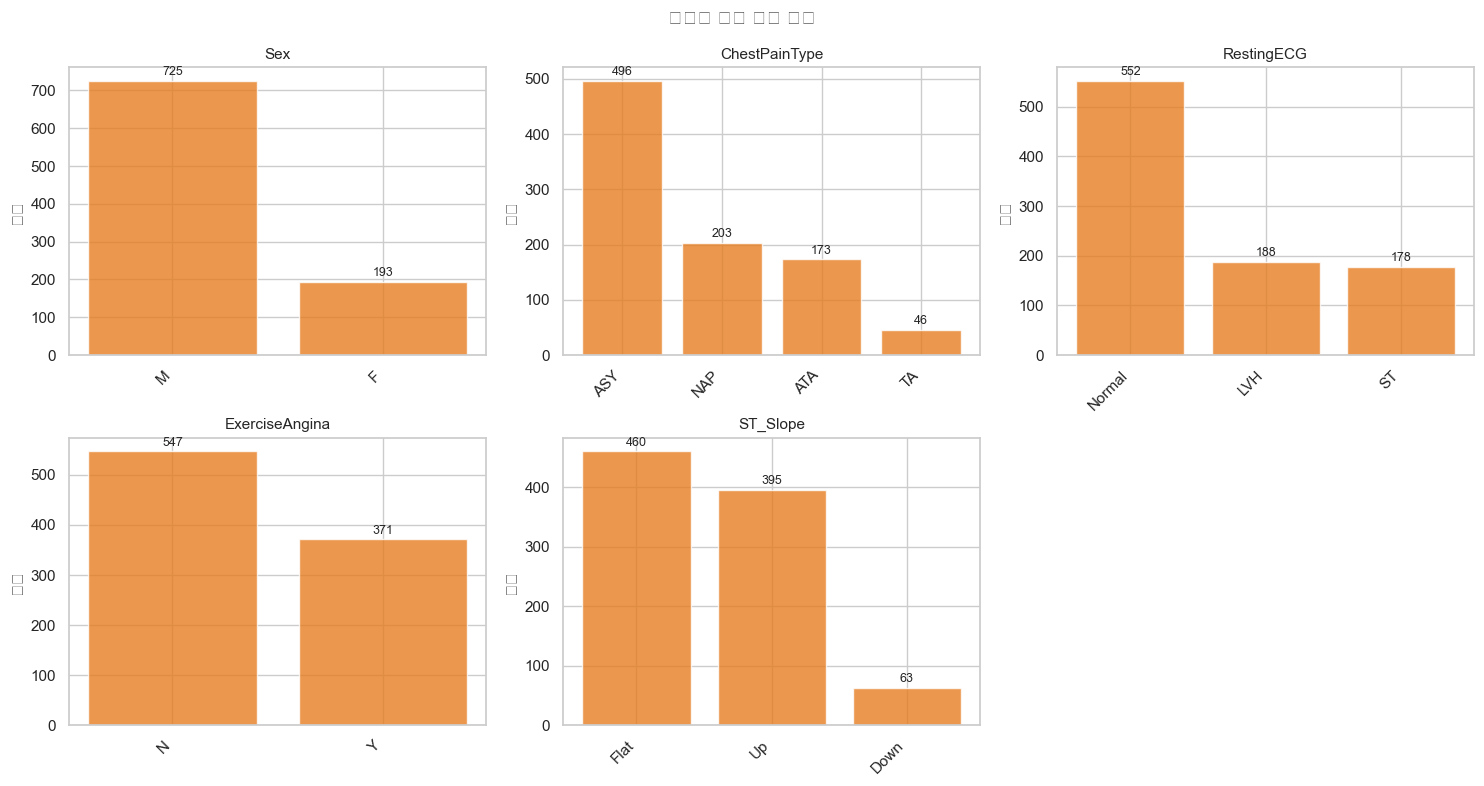

In [15]:
# ── 범주형: 빈도표 + 바차트 ──────────────────────────────────────────────────
if not cat_feats:
    print('범주형 피처 없음')
else:
    for col in cat_feats:
        freq = df[col].value_counts().reset_index()
        freq.columns = [col, '빈도']
        freq['비율(%)'] = (freq['빈도'] / len(df) * 100).round(2)
        display(
            freq.style
            .background_gradient(cmap='Blues', subset=['빈도'])
            .format({'비율(%)': '{:.2f}%'})
            .set_caption(f'{col} 빈도 분포')
        )

    N_COLS = min(3, len(cat_feats))
    n_rows = -(-len(cat_feats) // N_COLS)
    fig, axes = plt.subplots(n_rows, N_COLS,
                              figsize=(5 * N_COLS, 4 * n_rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cat_feats):
        vc = df[col].value_counts()
        bars = axes[i].bar(range(len(vc)), vc.values,
                           color='#e67e22', alpha=0.8, edgecolor='white')
        axes[i].set_xticks(range(len(vc)))
        axes[i].set_xticklabels(vc.index, rotation=45, ha='right')
        axes[i].set_title(col, fontsize=11)
        axes[i].set_ylabel('빈도')
        _gap = max(vc.values) * 0.01
        for j_b, v in enumerate(vc.values):
            axes[i].text(j_b, v + _gap, str(v),
                         ha='center', va='bottom', fontsize=9)

    for j in range(len(cat_feats), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('범주형 피처 빈도 분포', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 3.6 클래스 분포 분석

타겟 변수(`HeartDisease`)의 전체 클래스 비율을 확인합니다.

클래스 분포:
  Class 0: 410건  (44.7%)
  Class 1: 508건  (55.3%)


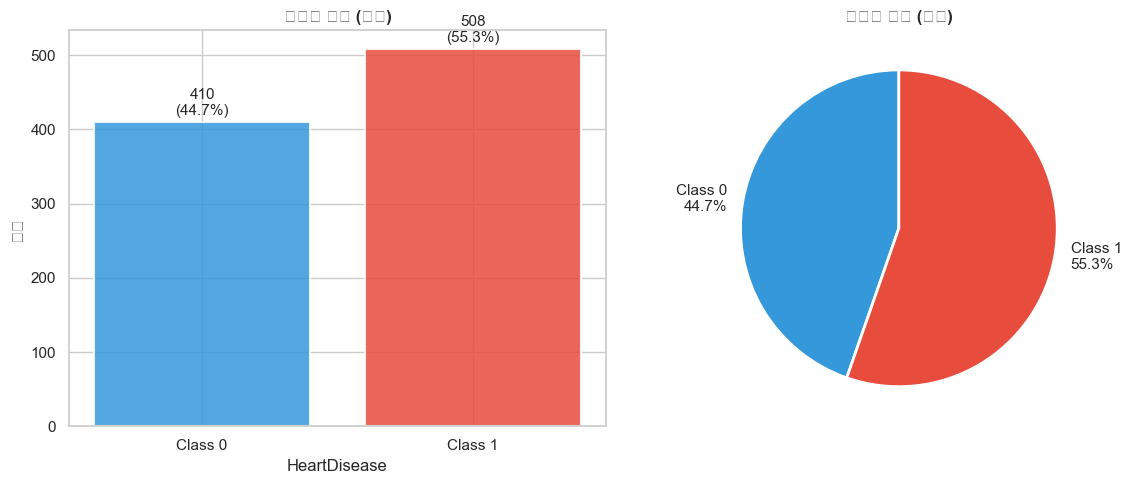

In [16]:
vc  = df[TARGET].value_counts().sort_index()
pct = df[TARGET].value_counts(normalize=True).sort_index() * 100
min_ratio = float(pct.min())
IS_IMBALANCED = min_ratio < 30.0

print(f'클래스 분포:')
for cls, cnt, p in zip(vc.index, vc.values, pct.values):
    print(f'  Class {cls}: {cnt:,}건  ({p:.1f}%)')
if IS_IMBALANCED:
    print(f'\n[경고] 클래스 불균형 감지 — 소수 클래스 비율 {min_ratio:.1f}%')

PALETTE = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 막대 차트
labels = [f'Class {c}' for c in vc.index]
bars = axes[0].bar(labels, vc.values,
                   color=PALETTE[:len(vc)], alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, v, p in zip(bars, vc.values, pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(vc.values) * 0.01,
                 f'{v:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=11)
axes[0].set_title('클래스 분포 (빈도)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('빈도')
axes[0].set_xlabel(TARGET)

# 파이 차트
pie_labels = [f'Class {c}\n{p:.1f}%' for c, p in zip(vc.index, pct.values)]
axes[1].pie(vc.values, labels=pie_labels,
            colors=PALETTE[:len(vc)], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('클래스 분포 (비율)', fontsize=12, fontweight='bold')

if IS_IMBALANCED:
    fig.text(0.5, 1.02,
             f'!! 클래스 불균형 경고: 소수 클래스 비율 {min_ratio:.1f}%',
             ha='center', va='bottom', fontsize=12, color='white', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#e74c3c', alpha=0.9))

plt.tight_layout()
plt.show()

### 3.6.1 피처 × 타겟 교차 분포

- **수치형** → 클래스별 겹친 히스토그램  
- **범주형** → 스택 바 차트  
- 클래스 불균형 시 차트 상단에 경고 배너 표시

=== 피처 x 타겟 교차 분포  (총 11개 피처) ===

[Age]


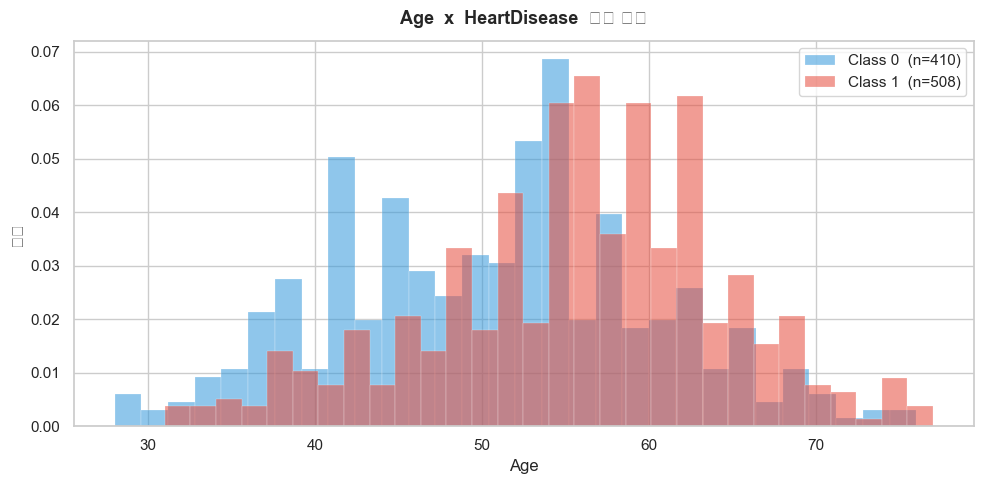


[RestingBP]


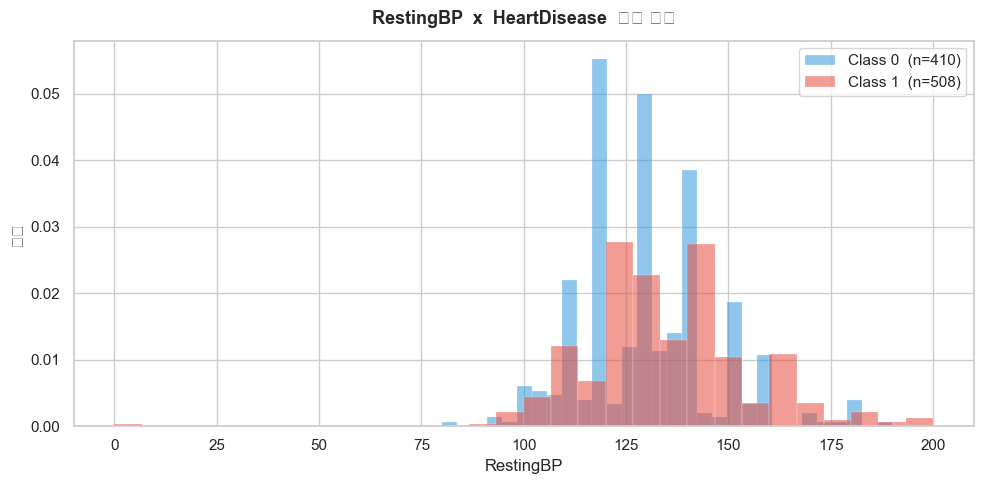


[Cholesterol]


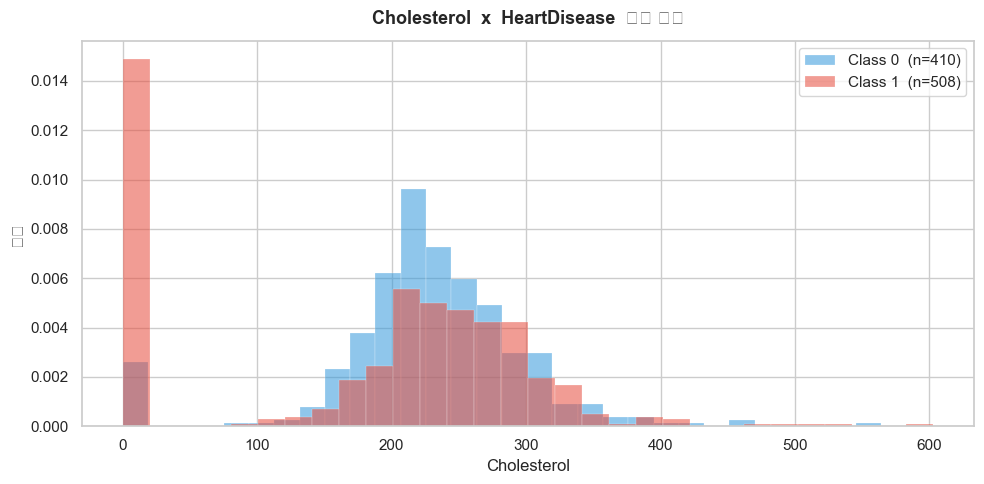


[FastingBS]


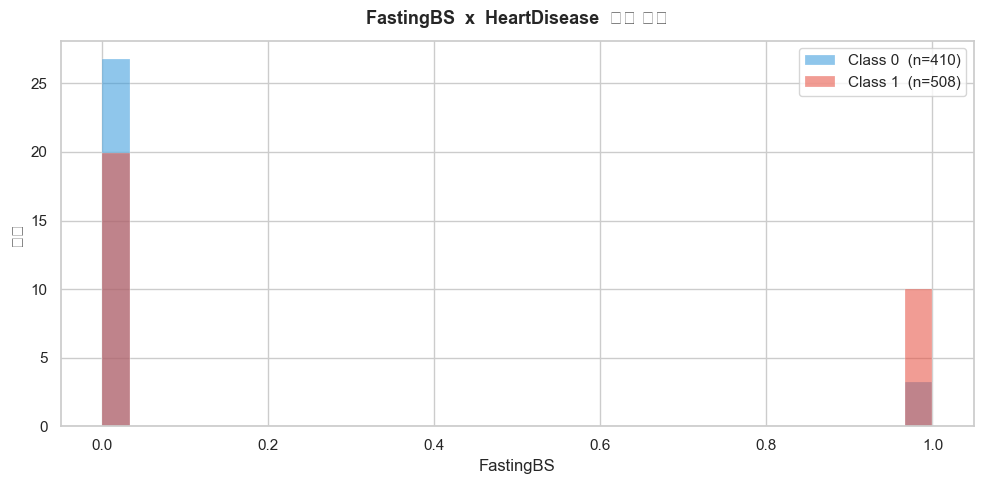


[MaxHR]


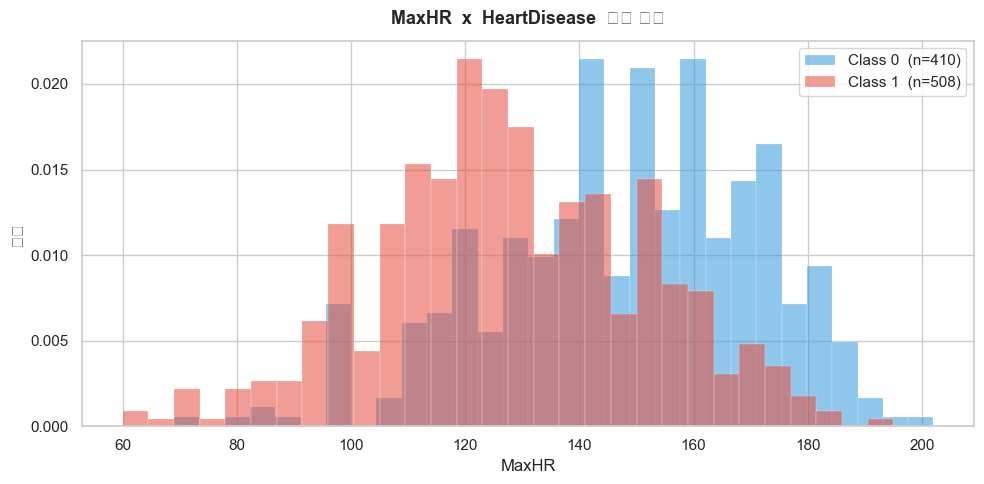


[Oldpeak]


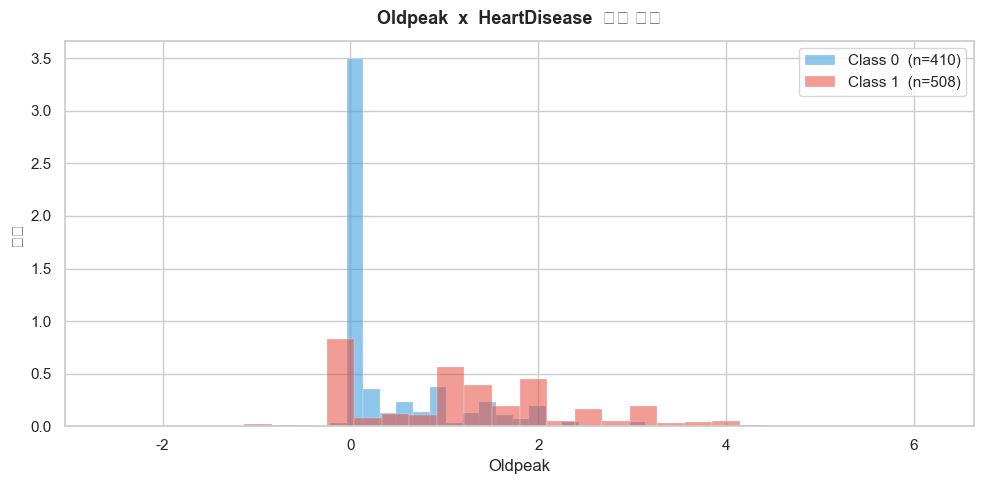


[Sex]


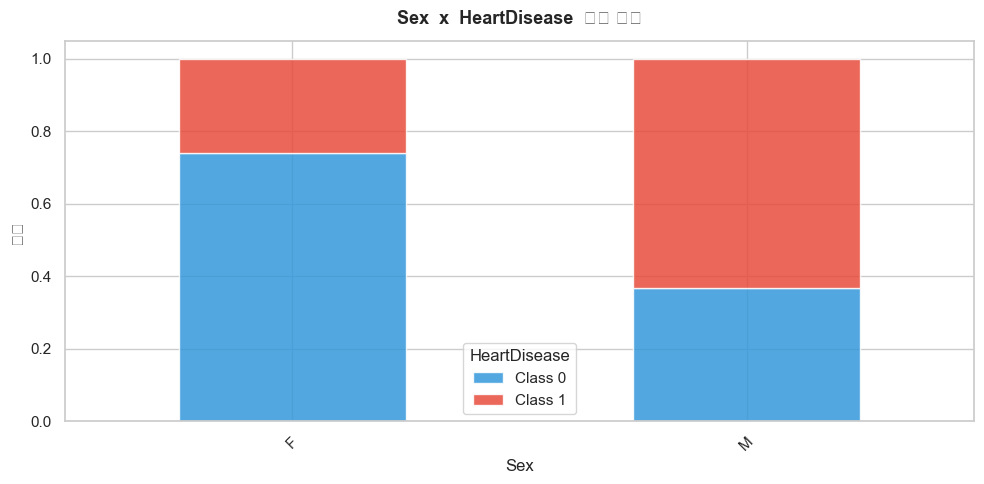


[ChestPainType]


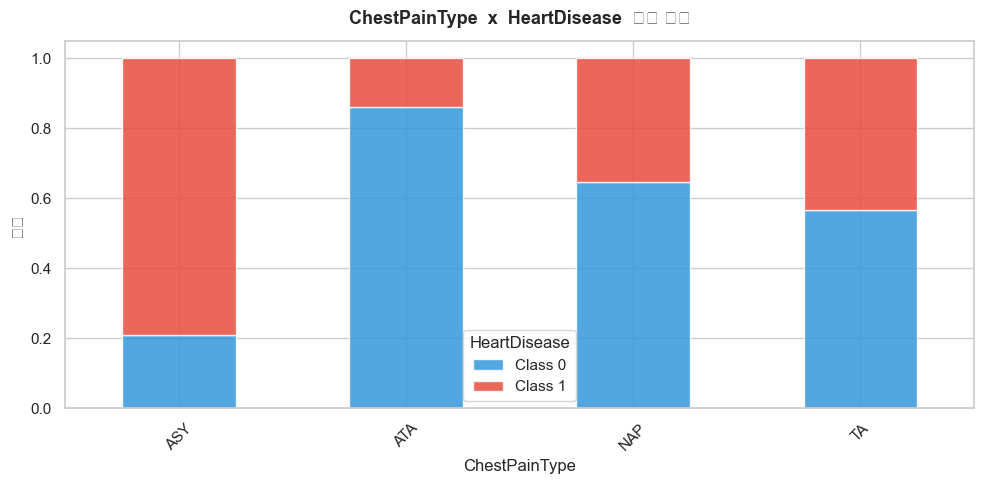


[RestingECG]


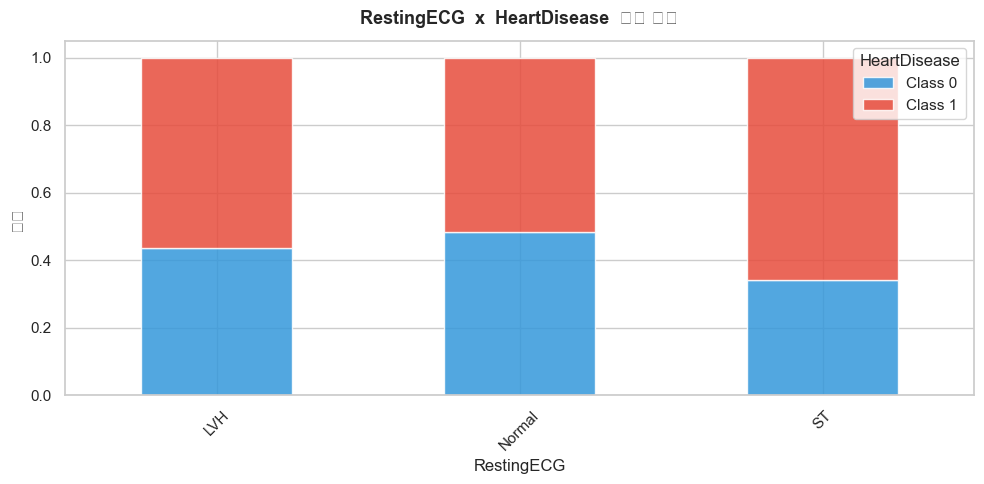


[ExerciseAngina]


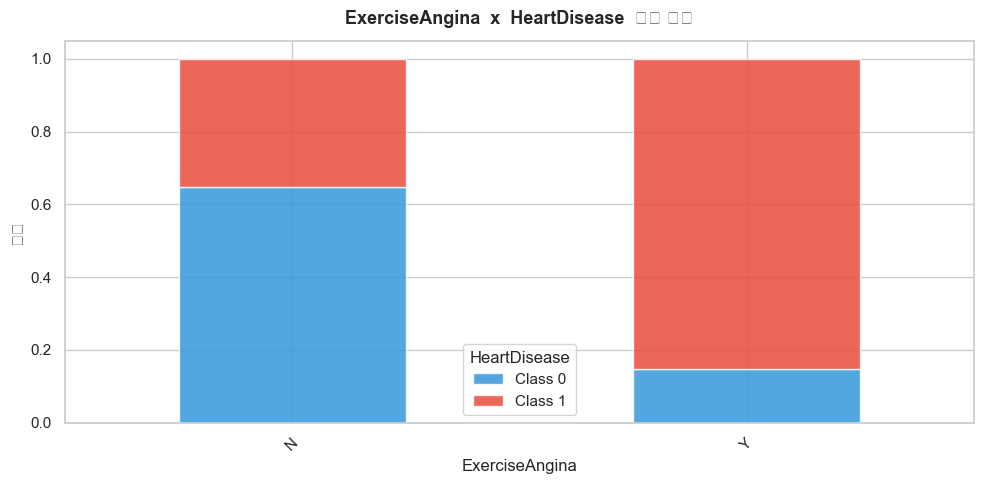


[ST_Slope]


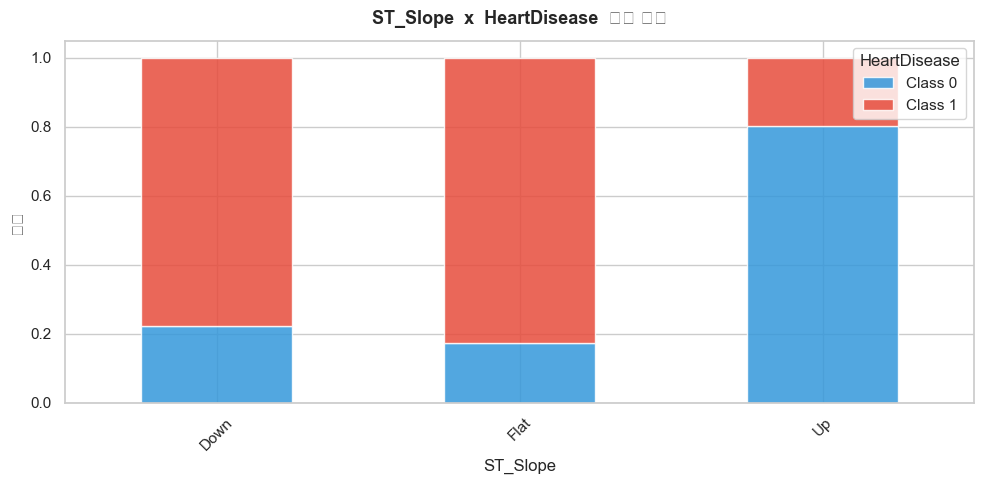

In [17]:
def plot_feature_vs_target(feat, df, target, num_feats, cat_feats, is_imbalanced, min_ratio):
    classes = sorted(df[target].unique())
    PAL = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
    title_pad = 30 if is_imbalanced else 12

    fig, ax = plt.subplots(figsize=(10, 5))

    if feat in num_feats:
        for idx, cls in enumerate(classes):
            subset = df[df[target] == cls][feat].dropna()
            ax.hist(subset, bins=30, alpha=0.55, density=True,
                    label=f'Class {cls}  (n={len(subset):,})',
                    color=PAL[idx % len(PAL)], edgecolor='white', linewidth=0.3)
        ax.set_xlabel(feat, fontsize=12)
        ax.set_ylabel('밀도', fontsize=12)
        ax.legend(fontsize=11)

    else:  # 범주형
        ct = pd.crosstab(df[feat], df[target], normalize='index')
        ct.columns = [f'Class {c}' for c in ct.columns]
        ct.plot(kind='bar', stacked=True, ax=ax,
                color=PAL[:len(classes)], alpha=0.85, edgecolor='white')
        ax.set_xlabel(feat, fontsize=12)
        ax.set_ylabel('비율', fontsize=12)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title=target, fontsize=11)

    if is_imbalanced:
        ax.text(
            0.5, 1.06,
            f'!! 클래스 불균형 경고: 소수 클래스 비율 {min_ratio:.1%}',
            transform=ax.transAxes, ha='center', va='bottom',
            fontsize=11, color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#e74c3c', alpha=0.9)
        )

    ax.set_title(f'{feat}  x  {target}  교차 분포',
                 fontsize=13, fontweight='bold', pad=title_pad)
    plt.tight_layout()
    plt.show()


print(f'=== 피처 x 타겟 교차 분포  (총 {len(all_feats)}개 피처) ===')
for feat in all_feats:
    print(f'\n[{feat}]')
    plot_feature_vs_target(feat, df, TARGET, num_feats, cat_feats,
                           IS_IMBALANCED, min_ratio / 100)

### 3.6.2 타겟 분리도 지표

| 피처 유형 | 지표 | 설명 |
|-----------|------|------|
| 수치형 | KS 통계량 | 두 클래스의 누적분포 최대 차이 (0→1, 클수록 좋음) |
| 수치형 | AUC | 단변량 분류 성능 (0.5→1, 클수록 좋음) |
| 범주형 | 카이제곱 | 독립성 검정 통계량 (클수록 타겟과 연관) |
| 범주형 | Information Gain | 엔트로피 감소량 (클수록 분리 잘 됨) |

In [18]:
# ── 수치형 피처 분리도: KS 통계량 + AUC ──────────────────────────────────────
y = df[TARGET]
classes = sorted(y.unique())

sep_num_rows = []
for col in num_feats:
    mask = df[col].notna()
    x_v  = df.loc[mask, col]
    y_v  = y[mask]
    c0   = x_v[y_v == classes[0]]
    c1   = x_v[y_v == classes[1]]

    ks_stat, ks_p = ks_2samp(c0, c1)
    try:
        auc = roc_auc_score(y_v, x_v)
        auc = max(auc, 1 - auc)   # 방향 보정
    except Exception:
        auc = 0.5

    sep_num_rows.append({
        '피처': col,
        'KS 통계량': round(ks_stat, 4),
        'KS p-value': round(ks_p, 4),
        'AUC': round(auc, 4)
    })

sep_num_df = (pd.DataFrame(sep_num_rows)
                .sort_values('AUC', ascending=False)
                .reset_index(drop=True))

display(
    sep_num_df.style
    .background_gradient(cmap='Blues', subset=['KS 통계량', 'AUC'])
    .format({'KS 통계량': '{:.4f}', 'KS p-value': '{:.4f}', 'AUC': '{:.4f}'})
    .set_caption('수치형 피처 분리도 지표 (AUC 내림차순)')
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '13px'), ('font-weight', 'bold')]
    }])
)

,피처,KS 통계량,KS p-value,AUC
0,Oldpeak,0.4328,0.0000,0.7351
1,MaxHR,0.3747,0.0000,0.7350
2,Age,0.2805,0.0000,0.6681
3,FastingBS,0.2273,0.0000,0.6137
4,Cholesterol,0.2554,0.0000,0.5810
5,RestingBP,0.1267,0.0012,0.5659


In [19]:
# ── 범주형 피처 분리도: 카이제곱 + Information Gain ───────────────────────────
le = LabelEncoder()
sep_cat_rows = []

for col in cat_feats:
    ct = pd.crosstab(df[col], y)
    chi2_stat, chi2_p, _, _ = chi2_contingency(ct)

    x_enc = le.fit_transform(df[col].astype(str)).reshape(-1, 1)
    ig = mutual_info_classif(x_enc, y, discrete_features=True, random_state=42)[0]

    sep_cat_rows.append({
        '피처': col,
        '카이제곱': round(chi2_stat, 4),
        'p-value': round(chi2_p, 6),
        'Information Gain': round(ig, 4)
    })

if sep_cat_rows:
    sep_cat_df = (pd.DataFrame(sep_cat_rows)
                    .sort_values('Information Gain', ascending=False)
                    .reset_index(drop=True))
    display(
        sep_cat_df.style
        .background_gradient(cmap='Oranges', subset=['카이제곱', 'Information Gain'])
        .format({'카이제곱': '{:.4f}', 'p-value': '{:.6f}', 'Information Gain': '{:.4f}'})
        .set_caption('범주형 피처 분리도 지표 (IG 내림차순)')
        .set_table_styles([{
            'selector': 'caption',
            'props': [('font-size', '13px'), ('font-weight', 'bold')]
        }])
    )
else:
    print('범주형 피처 없음')

,피처,카이제곱,p-value,Information Gain
0,ST_Slope,355.9184,0.000000,0.2075
1,ChestPainType,268.0672,0.000000,0.1560
2,ExerciseAngina,222.2594,0.000000,0.1317
3,Sex,84.1451,0.000000,0.0475
4,RestingECG,10.9315,0.004229,0.0060


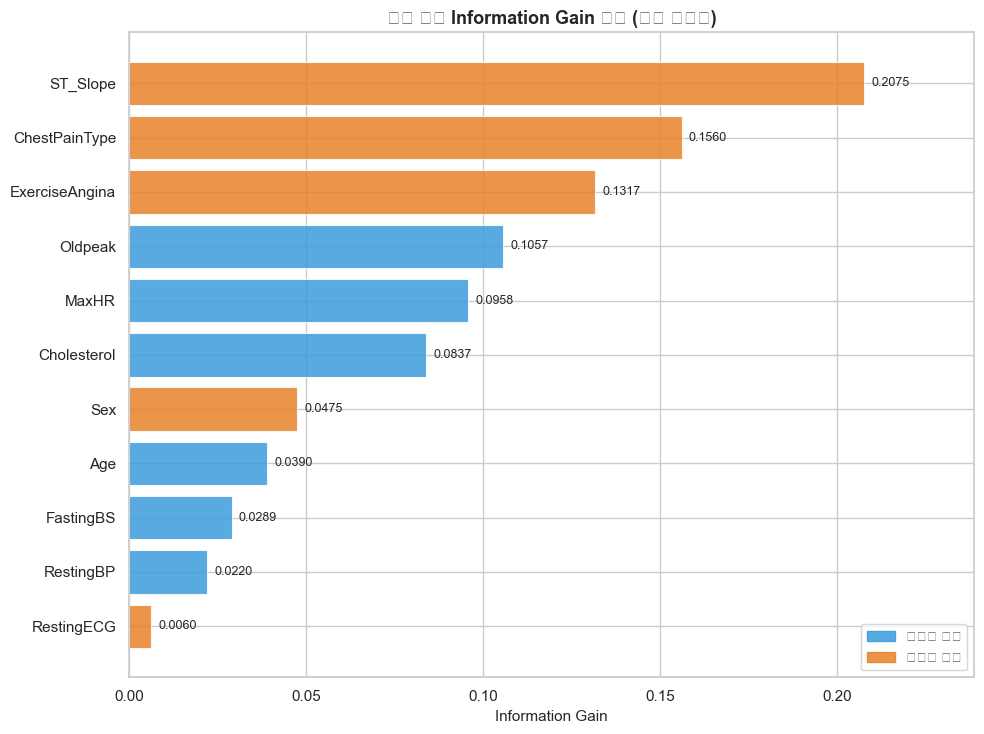


[완료] EDA 전 구간 분석 종료


In [20]:
# ── 전체 피처 Information Gain 랭킹 ──────────────────────────────────────────
all_ig = {}

for col in num_feats:
    x_col = df[[col]].fillna(df[col].median())
    all_ig[col] = mutual_info_classif(
        x_col, y, discrete_features=False, random_state=42
    )[0]

for col in cat_feats:
    x_enc = le.fit_transform(df[col].astype(str)).reshape(-1, 1)
    all_ig[col] = mutual_info_classif(
        x_enc, y, discrete_features=True, random_state=42
    )[0]

ig_series = pd.Series(all_ig).sort_values(ascending=True)
bar_colors = ['#e67e22' if f in cat_feats else '#3498db' for f in ig_series.index]

fig, ax = plt.subplots(figsize=(10, max(6, len(all_feats) * 0.5 + 2)))
bars = ax.barh(ig_series.index, ig_series.values,
               color=bar_colors, alpha=0.82, edgecolor='white', linewidth=0.8)

_max_ig = ig_series.max()
for bar, val in zip(bars, ig_series.values):
    ax.text(val + _max_ig * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left', fontsize=9)

ax.legend(
    handles=[
        mpatches.Patch(color='#3498db', alpha=0.82, label='수치형 피처'),
        mpatches.Patch(color='#e67e22', alpha=0.82, label='범주형 피처')
    ],
    loc='lower right', fontsize=10
)
ax.set_title('전체 피처 Information Gain 랭킹 (타겟 분리도)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Information Gain', fontsize=11)
ax.set_xlim(0, _max_ig * 1.15)
plt.tight_layout()
plt.show()

print('\n[완료] EDA 전 구간 분석 종료')

## 4. 전처리 (Preprocessing)

---

| 단계 | 처리 항목 |
|------|-----------|
| 4.1 중복 제거 | 완전 중복 행 삭제 |
| 4.2 결측치 처리 | 수치형: 행 삭제/평균/중앙값 (결측률 기반) · 범주형: 행 삭제/최빈값 |
| 4.3 이상치 처리 | IQR 기반 행 제거 또는 유지 |
| 4.4 인코딩 | 저카디널리티 → One-Hot · 고카디널리티 → Label |
| 4.5 스케일링 | StandardScaler / MinMaxScaler / RobustScaler / 미적용 |

In [31]:
# ========== 전처리 설정 파라미터 ==========
PP_CONFIG = {
    # 결측치
    'missing_num_strategy'  : 'median',  # 'drop' | 'mean' | 'median'
    'missing_num_threshold' : 5.0,       # 결측률(%) >= 이 값 → 행 삭제
    'missing_cat_strategy'  : 'mode',    # 'drop' | 'mode'

    # 이상치
    'outlier_strategy'      : 'keep',    # 'remove' | 'keep'

    # 인코딩: 고유값 <= N → One-Hot  /  > N → Label Encoding
    'ohe_cardinality_n'     : 10,

    # 스케일링 (tree 계열은 'none' 권장)
    'scaler'                : 'standard',# 'standard' | 'minmax' | 'robust' | 'none'
}

print('전처리 설정:')
for _k, _v in PP_CONFIG.items():
    print(f'  {_k}: {_v}')

전처리 설정:
  missing_num_strategy: median
  missing_num_threshold: 5.0
  missing_cat_strategy: mode
  outlier_strategy: keep
  ohe_cardinality_n: 10
  scaler: standard


### 4.1 중복 데이터 제거

In [32]:
n_before = len(df)
df_clean = df.drop_duplicates().reset_index(drop=True)
n_after  = len(df_clean)
n_dup    = n_before - n_after

print(f'제거 전 : {n_before:,}행')
print(f'제거 후 : {n_after:,}행')
print(f'중복 제거: {n_dup}건  ({n_dup / n_before:.2%})')

제거 전 : 918행
제거 후 : 918행
중복 제거: 0건  (0.00%)


### 4.2 결측치 처리

- **수치형**: 결측률 ≥ `missing_num_threshold`% → 행 삭제, 그 미만 → `mean` 또는 `median` 대체
- **범주형**: `mode`(최빈값) 대체 또는 행 삭제

In [33]:
strategy_num  = PP_CONFIG['missing_num_strategy']
threshold_pct = PP_CONFIG['missing_num_threshold']
strategy_cat  = PP_CONFIG['missing_cat_strategy']

miss_total = df_clean.isnull().sum().sum()

if miss_total == 0:
    print('결측치 없음 — 처리 생략')
else:
    num_present = [c for c in num_feats if c in df_clean.columns]
    cat_present = [c for c in cat_feats if c in df_clean.columns]

    for col in num_present:
        n_miss = df_clean[col].isnull().sum()
        if n_miss == 0:
            continue
        miss_pct = n_miss / len(df_clean) * 100
        if miss_pct >= threshold_pct or strategy_num == 'drop':
            df_clean = df_clean[df_clean[col].notna()].reset_index(drop=True)
            print(f'  [수치형·행삭제]  {col}: 결측률 {miss_pct:.1f}%')
        elif strategy_num == 'mean':
            fv = df_clean[col].mean()
            df_clean[col] = df_clean[col].fillna(fv)
            print(f'  [수치형·평균]    {col}: {fv:.4f} 대체 ({n_miss}건)')
        else:
            fv = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(fv)
            print(f'  [수치형·중앙값]  {col}: {fv:.4f} 대체 ({n_miss}건)')

    for col in cat_present:
        n_miss = df_clean[col].isnull().sum()
        if n_miss == 0:
            continue
        if strategy_cat == 'drop':
            df_clean = df_clean[df_clean[col].notna()].reset_index(drop=True)
            print(f'  [범주형·행삭제]  {col} ({n_miss}건)')
        else:
            fv = df_clean[col].mode()[0]
            df_clean[col] = df_clean[col].fillna(fv)
            print(f'  [범주형·최빈값]  {col}: "{fv}" 대체 ({n_miss}건)')

print(f'결측치 처리 후 Shape: {df_clean.shape}')

결측치 없음 — 처리 생략
결측치 처리 후 Shape: (918, 12)


### 4.3 이상치 처리 (IQR 기반)

`outlier_strategy = 'remove'` : IQR 기준 초과 행 제거
`outlier_strategy = 'keep'`   : 원본 유지

In [34]:
strategy_out = PP_CONFIG['outlier_strategy']
n_before_out = len(df_clean)

if strategy_out == 'remove':
    keep_mask = pd.Series([True] * len(df_clean), index=df_clean.index)
    out_log = []
    for col in [c for c in num_feats if c in df_clean.columns]:
        q1, q3  = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
        iqr     = q3 - q1
        lower   = q1 - 1.5 * iqr
        upper   = q3 + 1.5 * iqr
        col_ok  = (df_clean[col] >= lower) & (df_clean[col] <= upper)
        n_out   = (~col_ok).sum()
        if n_out > 0:
            out_log.append({'컬럼': col, '이상치 건수': n_out,
                            '하한': round(lower, 4), '상한': round(upper, 4)})
        keep_mask = keep_mask & col_ok

    df_clean = df_clean[keep_mask].reset_index(drop=True)
    n_removed = n_before_out - len(df_clean)

    if out_log:
        display(pd.DataFrame(out_log).style
                .background_gradient(cmap='Oranges', subset=['이상치 건수'])
                .set_caption('IQR 이상치 제거 내역'))
    print(f'제거 전: {n_before_out:,}행  →  제거 후: {len(df_clean):,}행  (제거: {n_removed}건)')

elif strategy_out == 'keep':
    print(f'이상치 유지  |  현재 Shape: {df_clean.shape}')

이상치 유지  |  현재 Shape: (918, 12)


### 4.4 인코딩 (범주형 피처 대상)

| 조건 | 방법 | 비고 |
|------|------|------|
| 고유값 ≤ `ohe_cardinality_n` | One-Hot Encoding | 저카디널리티 |
| 고유값 > `ohe_cardinality_n` | Label Encoding   | 고카디널리티 (순서 없는 범주 주의) |

In [35]:
N = PP_CONFIG['ohe_cardinality_n']
_le = LabelEncoder()

cat_present = [c for c in cat_feats if c in df_clean.columns]
ohe_cols, le_cols, enc_log = [], [], []

for col in cat_present:
    card = df_clean[col].nunique()
    if card <= N:
        ohe_cols.append(col)
        enc_log.append({'컬럼': col, '카디널리티': card, '인코딩': 'One-Hot'})
    else:
        le_cols.append(col)
        enc_log.append({'컬럼': col, '카디널리티': card, '인코딩': 'Label (고카디널리티)'})

if enc_log:
    def _enc_color(s):
        return ['color:#27ae60;font-weight:bold' if v == 'One-Hot'
                else 'color:#e74c3c;font-weight:bold' for v in s]
    display(pd.DataFrame(enc_log).style
            .apply(_enc_color, subset=['인코딩'])
            .background_gradient(cmap='Blues', subset=['카디널리티'])
            .set_caption(f'인코딩 전략  (OHE 임계값: 카디널리티 ≤ {N})'))

for col in le_cols:
    df_clean[col] = _le.fit_transform(df_clean[col].astype(str))
    print(f'  [Label Enc]   {col}')

if ohe_cols:
    df_clean = pd.get_dummies(df_clean, columns=ohe_cols, dtype=int)
    new_ohe  = [c for c in df_clean.columns if any(c.startswith(p + '_') for p in ohe_cols)]
    print(f'  [One-Hot Enc] 원본 컬럼: {ohe_cols}')
    print(f'  [One-Hot Enc] 생성 컬럼: {new_ohe}')

print(f'\n인코딩 후 Shape: {df_clean.shape}')

,컬럼,카디널리티,인코딩
0,Sex,2,One-Hot
1,ChestPainType,4,One-Hot
2,RestingECG,3,One-Hot
3,ExerciseAngina,2,One-Hot
4,ST_Slope,3,One-Hot


  [One-Hot Enc] 원본 컬럼: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
  [One-Hot Enc] 생성 컬럼: ['Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']

인코딩 후 Shape: (918, 21)


### 4.5 스케일링 (수치형 피처 대상)

| 스케일러 | 설명 |
|----------|------|
| `standard` | 평균=0, 분산=1 정규화 (Z-score) |
| `minmax`   | [0, 1] 범위로 압축 |
| `robust`   | 중앙값·IQR 기반 — 이상치에 강건 |
| `none`     | 미적용 (트리 계열 모델 권장) |

In [36]:
scaler_name = PP_CONFIG['scaler']

# 이진(0/1) 컬럼 및 TARGET 제외하고 수치형만 스케일링
num_to_scale = [
    c for c in df_clean.columns
    if c != TARGET
    and pd.api.types.is_numeric_dtype(df_clean[c])
    and df_clean[c].nunique() > 2
]

df_processed = df_clean.copy()

if scaler_name == 'none':
    print('스케일링 미적용  (tree 계열 모델 권장)')
else:
    _SCALERS = {
        'standard': (StandardScaler(), 'StandardScaler  (평균=0, 분산=1)'),
        'minmax'  : (MinMaxScaler(),   'MinMaxScaler  (범위 [0, 1])'),
        'robust'  : (RobustScaler(),   'RobustScaler  (중앙값·IQR 기반)'),
    }
    scaler_obj, scaler_label = _SCALERS[scaler_name]
    df_processed[num_to_scale] = scaler_obj.fit_transform(df_clean[num_to_scale])

    before = df_clean[num_to_scale].agg(['mean', 'std']).T.round(4)
    after  = df_processed[num_to_scale].agg(['mean', 'std']).T.round(4)
    cmp    = pd.concat([before, after], axis=1)
    cmp.columns = ['평균 (before)', '표준편차 (before)', '평균 (after)', '표준편차 (after)']
    display(cmp.style
            .background_gradient(cmap='Blues', subset=['평균 (after)', '표준편차 (after)'])
            .format('{:.4f}')
            .set_caption(f'스케일링 전후 비교  ({scaler_label})'))
    print(f'스케일러: {scaler_label}')
    print(f'적용 컬럼 ({len(num_to_scale)}개): {num_to_scale}')

print(f'\n최종 전처리 완료  Shape: {df_processed.shape}')

,평균 (before),표준편차 (before),평균 (after),표준편차 (after)
Age,53.5109,9.4326,-0.0000,1.0005
RestingBP,132.3965,18.5142,0.0000,1.0005
Cholesterol,198.7996,109.3841,0.0000,1.0005
MaxHR,136.8094,25.4603,0.0000,1.0005
Oldpeak,0.8874,1.0666,0.0000,1.0005


스케일러: StandardScaler  (평균=0, 분산=1)
적용 컬럼 (5개): ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

최종 전처리 완료  Shape: (918, 21)


### 4.6 전처리 결과 요약

In [37]:
X     = df_processed.drop(columns=[TARGET])
y_proc = df_processed[TARGET]

_sum = [
    {'단계': '① 원본 데이터',          '행': len(df),              '컬럼': df.shape[1]},
    {'단계': '② 중복 제거',            '행': n_after,              '컬럼': df.shape[1]},
    {'단계': '③ 결측치 처리',          '행': df_clean.shape[0],    '컬럼': df_clean.shape[1]},
    {'단계': '④ 이상치 처리',          '행': df_clean.shape[0],    '컬럼': df_clean.shape[1]},
    {'단계': '⑤ 인코딩 + 스케일링',   '행': df_processed.shape[0],'컬럼': df_processed.shape[1]},
]
display(pd.DataFrame(_sum).style
        .background_gradient(cmap='Blues', subset=['행', '컬럼'])
        .set_caption('전처리 단계별 데이터 변화'))

print(f'\nX shape : {X.shape}')
print(f'y shape : {y_proc.shape}')
print(f'\nX 컬럼  : {list(X.columns)}')
print('\n[완료] 전처리 종료')

,단계,행,컬럼
0,① 원본 데이터,918,12
1,② 중복 제거,918,12
2,③ 결측치 처리,918,21
3,④ 이상치 처리,918,21
4,⑤ 인코딩 + 스케일링,918,21



X shape : (918, 20)
y shape : (918,)

X 컬럼  : ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']

[완료] 전처리 종료


In [38]:
import pickle

# artifacts 디렉터리 생성
ARTIFACTS_DIR = os.path.join(os.getcwd(), 'artifacts')
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

_payload = {
    'X'            : X,
    'y'            : y_proc,
    'df_processed' : df_processed,
    'TARGET'       : TARGET,
    'feature_names': list(X.columns),
    'num_feats'    : num_feats,
    'cat_feats'    : cat_feats,
    'all_feats'    : all_feats,
}

_pkl_path = os.path.join(ARTIFACTS_DIR, 'preprocessed_data.pkl')
with open(_pkl_path, 'wb') as _f:
    pickle.dump(_payload, _f)

print(f'저장 완료 : {_pkl_path}')
print(f'X shape  : {X.shape}')
print(f'y shape  : {y_proc.shape}')
print(f'피처 목록: {list(X.columns)}')

저장 완료 : c:\work\project\workspace\algorithm_test\binary_classification\artifacts\preprocessed_data.pkl
X shape  : (918, 20)
y shape  : (918,)
피처 목록: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


## 5. 유의성 검증 — WoE / IV

| 지표 | 용도 |
|------|------|
| **WoE** (Weight of Evidence) | 구간별 예측력 방향성 / 강도 |
| **IV** (Information Value) | 피처 전체 예측력 |

| IV 값 | 등급 |
|-------|------|
| ≥ 0.3 | 강함 |
| 0.1 ~ 0.3 | 중간 |
| 0.02 ~ 0.1 | 약함 |
| < 0.02 | 무용 |

In [39]:
def compute_woe_iv(series, target, bins=10, min_bin_n=5):
    """WoE / IV 계산.  수치형: 등빈도 분구간,  범주형: 카테고리별."""
    tmp = pd.DataFrame({'x': series, 'y': target}).dropna()
    total_ev  = (tmp['y'] == 1).sum()
    total_nev = (tmp['y'] == 0).sum()
    if total_ev == 0 or total_nev == 0:
        return pd.DataFrame(), 0.0

    is_numeric_cont = (pd.api.types.is_numeric_dtype(series)
                       and series.nunique() > bins)
    if is_numeric_cont:
        tmp['bin'] = pd.qcut(tmp['x'], q=bins, duplicates='drop')
    else:
        tmp['bin'] = tmp['x'].astype(str)

    rows = []
    for bin_val, grp in tmp.groupby('bin', observed=True, sort=True):
        n_ev  = (grp['y'] == 1).sum()
        n_nev = (grp['y'] == 0).sum()
        if n_ev < min_bin_n or n_nev < min_bin_n:
            continue
        d_ev  = n_ev  / total_ev
        d_nev = n_nev / total_nev
        woe   = np.log(d_ev / d_nev)
        iv    = (d_ev - d_nev) * woe
        rows.append({'구간': str(bin_val),
                     'n_events': int(n_ev), 'n_non_events': int(n_nev),
                     'dist_events': round(d_ev, 6),
                     'dist_non_events': round(d_nev, 6),
                     'WoE': round(woe, 4),
                     'IV': round(iv, 4)})
    if not rows:
        return pd.DataFrame(), 0.0
    woe_df = pd.DataFrame(rows)
    return woe_df, float(woe_df['IV'].sum())


def iv_grade(iv):
    if iv >= 0.3:  return '강함'
    if iv >= 0.1:  return '중간'
    if iv >= 0.02: return '약함'
    return '무용'


GRADE_COLORS = {
    '강함': '#e74c3c',
    '중간': '#e67e22',
    '약함': '#f1c40f',
    '무용': '#95a5a6',
}

# 원본 df 사용 (스케일링 전 값으로 WoE 의미 보존)
y_orig = df[TARGET]
iv_results, woe_details = [], {}

for col in all_feats:
    wdf, total_iv = compute_woe_iv(df[col], y_orig)
    if not wdf.empty:
        grade = iv_grade(total_iv)
        iv_results.append({'피처': col, 'IV': round(total_iv, 4),
                           '등급': grade,
                           '유형': '수치형' if col in num_feats else '범주형'})
        woe_details[col] = wdf

iv_summary = (pd.DataFrame(iv_results)
              .sort_values('IV', ascending=False)
              .reset_index(drop=True))

def _grade_color_col(s):
    return [f'color:{GRADE_COLORS.get(v, "#333")};font-weight:bold' for v in s]

display(
    iv_summary.style
    .background_gradient(cmap='Blues', subset=['IV'])
    .apply(_grade_color_col, subset=['등급'])
    .format({'IV': '{:.4f}'})
    .set_caption('피처별 IV 및 등급')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
)
print(f'\n계산 완료: {len(iv_results)}개 피처')

,피처,IV,등급,유형
0,ST_Slope,1.8237,강함,범주형
1,ChestPainType,1.3774,강함,범주형
2,ExerciseAngina,1.1529,강함,범주형
3,Oldpeak,0.9645,강함,수치형
4,MaxHR,0.7925,강함,수치형
5,Cholesterol,0.5548,강함,수치형
6,Age,0.4324,강함,수치형
7,Sex,0.3981,강함,범주형
8,FastingBS,0.3253,강함,수치형
9,RestingBP,0.1697,중간,수치형



계산 완료: 11개 피처


### 5.1 IV Bar Chart — 피처별 IV 값, 등급별 색상

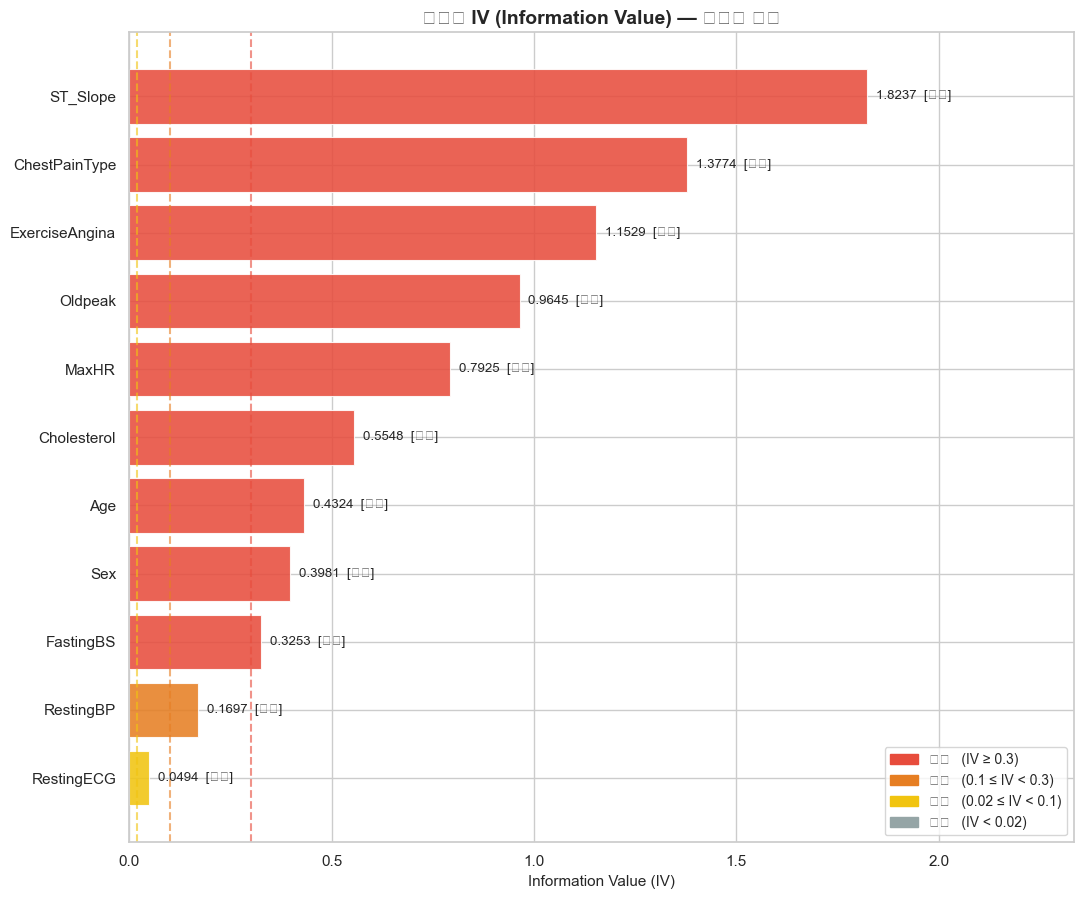

In [40]:
iv_sorted  = iv_summary.sort_values('IV', ascending=True).reset_index(drop=True)
bar_colors = [GRADE_COLORS[g] for g in iv_sorted['등급']]
_max_iv    = iv_sorted['IV'].max()

fig, ax = plt.subplots(figsize=(11, max(6, len(iv_sorted) * 0.65 + 2)))
bars = ax.barh(iv_sorted['피처'], iv_sorted['IV'],
               color=bar_colors, alpha=0.87, edgecolor='white', linewidth=0.8)

for bar, row in zip(bars, iv_sorted.itertuples()):
    ax.text(row.IV + _max_iv * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f'{row.IV:.4f}  [{row.등급}]',
            va='center', ha='left', fontsize=9.5)

# 등급 구분 기준선
for bound, lbl in [(0.3, '강함'), (0.1, '중간'), (0.02, '약함')]:
    if bound <= _max_iv * 1.05:
        ax.axvline(bound, color=GRADE_COLORS[lbl],
                   linewidth=1.5, linestyle='--', alpha=0.6)

ax.legend(
    handles=[
        mpatches.Patch(color='#e74c3c', label='강함   (IV ≥ 0.3)'),
        mpatches.Patch(color='#e67e22', label='중간   (0.1 ≤ IV < 0.3)'),
        mpatches.Patch(color='#f1c40f', label='약함   (0.02 ≤ IV < 0.1)'),
        mpatches.Patch(color='#95a5a6', label='무용   (IV < 0.02)'),
    ],
    loc='lower right', fontsize=10
)
ax.set_title('피처별 IV (Information Value) — 등급별 색상',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Information Value (IV)', fontsize=11)
ax.set_xlim(0, _max_iv * 1.28)
plt.tight_layout()
plt.show()

### 5.2 WoE Binning Plot — 선택 피처의 구간별 WoE 단조성 확인

- **양수 WoE**: 해당 구간에서 이벤트(Class 1) 비율이 비이벤트보다 높음
- **음수 WoE**: 해당 구간에서 비이벤트(Class 0) 비율이 이벤트보다 높음
- 단조 증가/감소 패턴 → 피처와 타겟 간 선형적 관계 (모델에 유리)

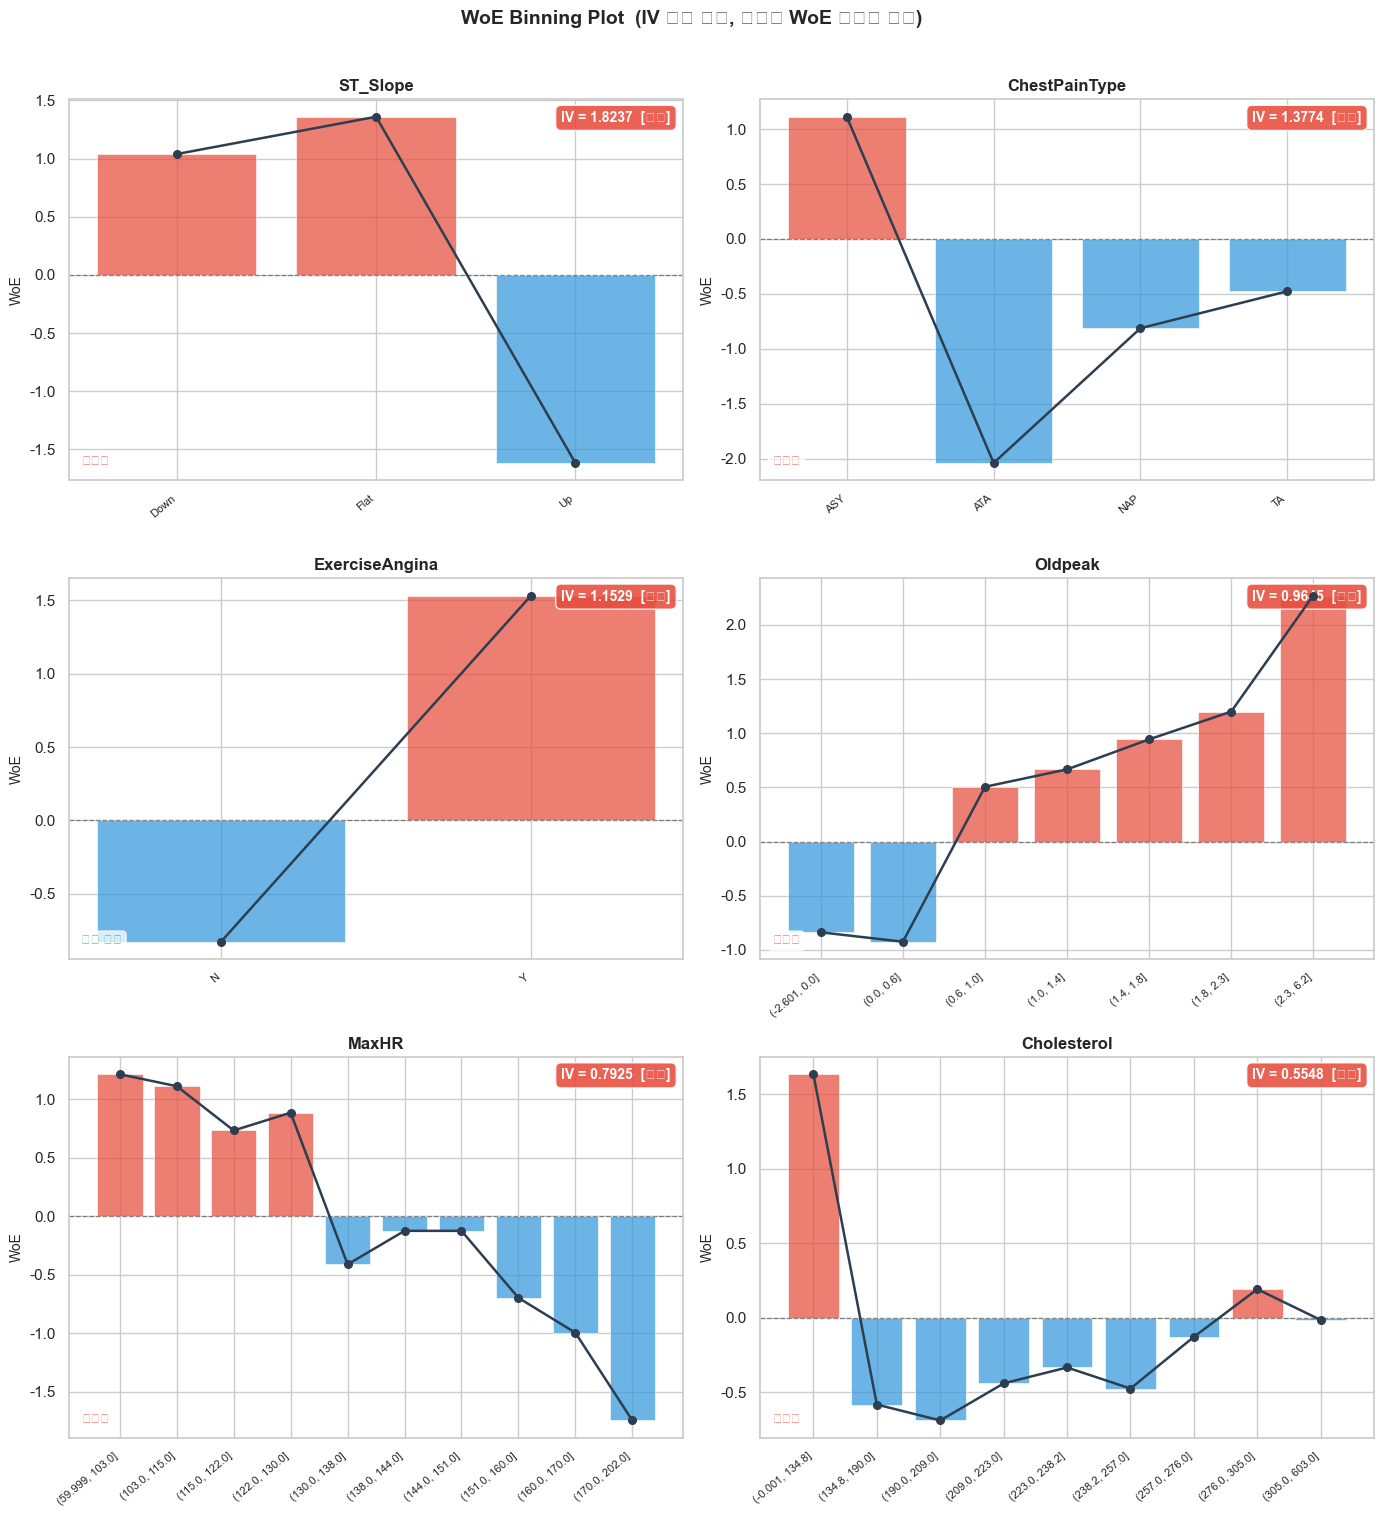


[완료] 유의성 검증 (WoE / IV) 종료


In [41]:
# IV 상위 피처 최대 6개 시각화
top_feats_woe = iv_summary.head(min(6, len(iv_summary)))['피처'].tolist()

N_COLS   = 2
n_rows_w = -(-len(top_feats_woe) // N_COLS)
fig, axes = plt.subplots(n_rows_w, N_COLS,
                          figsize=(14, 5 * n_rows_w))
axes = np.array(axes).flatten()

for i, feat in enumerate(top_feats_woe):
    wdf = woe_details[feat]
    ax  = axes[i]

    bar_clr = ['#e74c3c' if w >= 0 else '#3498db' for w in wdf['WoE']]
    ax.bar(range(len(wdf)), wdf['WoE'],
           color=bar_clr, alpha=0.72, edgecolor='white', linewidth=0.6)
    ax.plot(range(len(wdf)), wdf['WoE'],
            marker='o', color='#2c3e50', linewidth=1.8,
            markersize=5.5, zorder=5)
    ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.4)

    ax.set_xticks(range(len(wdf)))
    ax.set_xticklabels(wdf['구간'], rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('WoE', fontsize=10)
    ax.set_title(feat, fontsize=12, fontweight='bold')

    # IV / 등급 배지
    iv_val = iv_summary.loc[iv_summary['피처'] == feat, 'IV'].values[0]
    grade  = iv_summary.loc[iv_summary['피처'] == feat, '등급'].values[0]
    ax.text(0.98, 0.97, f'IV = {iv_val:.4f}  [{grade}]',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor=GRADE_COLORS.get(grade, '#333'), alpha=0.88))

    # 단조성 판별
    woe_arr = wdf['WoE'].values
    mono_up   = all(woe_arr[j] <= woe_arr[j+1] for j in range(len(woe_arr)-1))
    mono_down = all(woe_arr[j] >= woe_arr[j+1] for j in range(len(woe_arr)-1))
    mono_lbl  = '단조 증가' if mono_up else ('단조 감소' if mono_down else '비단조')
    mono_clr  = '#27ae60' if (mono_up or mono_down) else '#e74c3c'
    ax.text(0.02, 0.04, mono_lbl,
            transform=ax.transAxes, fontsize=9,
            color=mono_clr, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.75))

for j in range(len(top_feats_woe), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('WoE Binning Plot  (IV 상위 피처, 구간별 WoE 단조성 확인)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('\n[완료] 유의성 검증 (WoE / IV) 종료')